In [1]:
# function definitions moved to functions.py


# Top-NMF: Appendix 2

# Import Libraries

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from sklearn.decomposition._nmf import _initialize_nmf
from scipy.interpolate import make_interp_spline
from tqdm.notebook import tqdm

from TopNMF import *

device = 'cpu'

2026-01-18 17:21:56.305649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768724516.316908 1717562 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768724516.320387 1717562 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-18 17:21:56.332102: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


ModuleNotFoundError: No module named 'cubical_complex'

# Generate Synthetic Signals

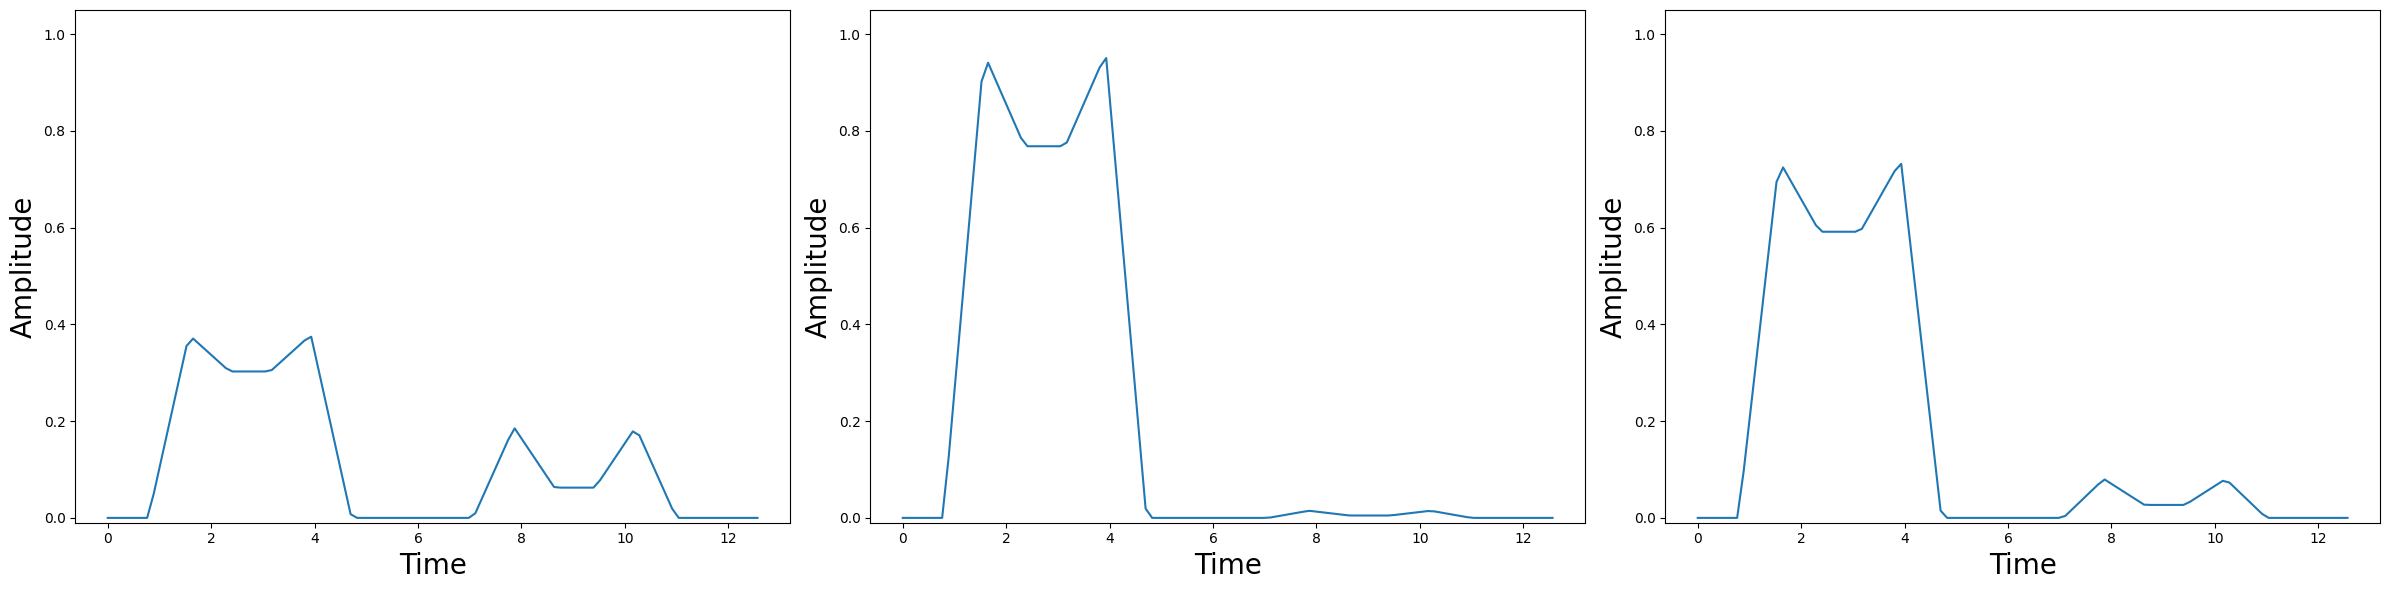

In [ ]:
# Generate base signals and mix to form dataset

x_anchor = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0])
y_anchor = np.array([0.0, 0.0, 1.0, 0.8, 0.8, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# First base shape
a_smooth = np.linspace(x_anchor.min(), x_anchor.max(), 100)
spline = make_interp_spline(x_anchor, y_anchor, k=1)
y_smooth_1 = spline(a_smooth)
y_smooth_1 /= np.max(y_smooth_1)



# Second base shape
y_anchor = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.1, 0.1, 0.3, 0.0, 0.0, 0.0])
spline = make_interp_spline(x_anchor, y_anchor, k=1)
y_smooth_2 = spline(a_smooth)



# Mix two shapes to create dataset
np.random.seed(42)
rand = np.random.rand(3)

# Fixed dataset (no randomness)
X_list = [
    y_smooth_1,
    y_smooth_2,
    y_smooth_1 + y_smooth_2
]

# Plot
t = np.linspace(0, 4 * np.pi, 100)
plt.figure(figsize=(24, 6))

for i, signal in enumerate(X_list):
    plt.subplot(1, len(X_list), i + 1)
    plt.plot(t, signal)
    plt.xlabel("Time", size=20)
    plt.ylabel("Amplitude", size=20)
    plt.ylim(-0.01, 1.05)

plt.tight_layout()
plt.show()

X = np.array(X_list)

# Run Top-NMF

  0%|          | 0/30000 [00:00<?, ?it/s]

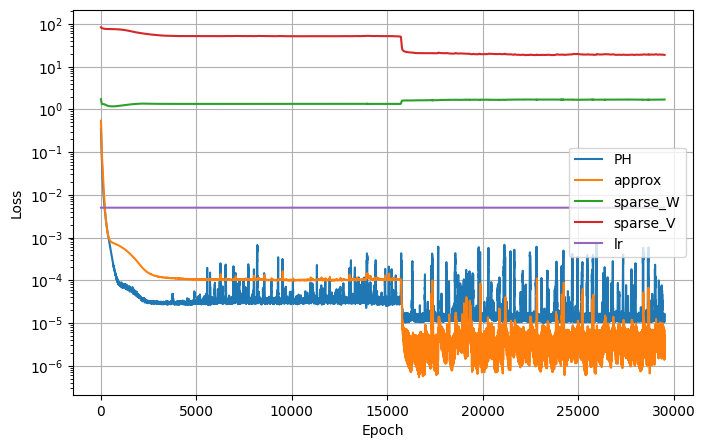

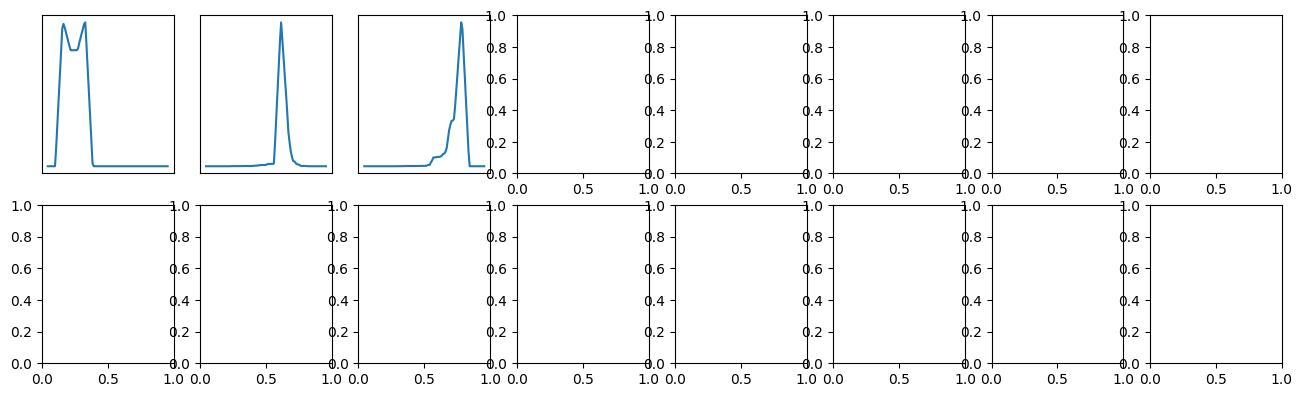

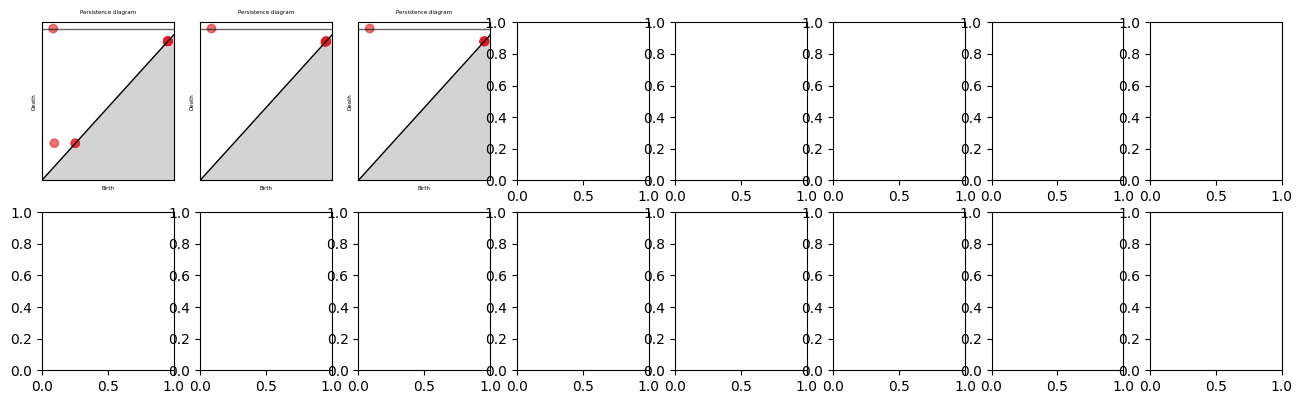

target L1/L2 ratio 0


In [ ]:
cubical_complex = CubicalComplex(
    superlevel=True,
    dim=len((X.shape[1],)),
    mode='V'
)


target_diagrams = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]


model = TopologicalNMF(
    n_components=3,
    device='cpu',
    complex=cubical_complex,
    ph_loss_fn=target_diagram_loss,
    data_shape=(X.shape[1],),
    use_embedding=False,
    random_state = 42
)

model.fit(
    X,
    n_iterations=15000,
    lr=0.005,
    lambda_top=0.5,
    PH_dims=[0],
    start_epoch_topological=0,
    show_plots=['loss', 'basis', 'PH'],
    disp_interval=10,
    verbose=True,
    target_diagrams = target_diagrams,
    init_method = 'nndsvdar',
    plot_grid = (4,8),
    superlevel=True, 
    PHmode='V',
    normalize_V_max = True
)
plt.close('all')